In [1]:
# Cell 1 - mounting
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import pandas as pd
import numpy as np

# Cell 2 — Load data
BASE = "/content/gdrive/Shareddrives/FML_FINAL/Data"

X = np.load(f"{BASE}/script_embeddings.npy")
df_meta = pd.read_csv(f"{BASE}/movies_with_embeddings.csv")
y = df_meta["log_roi"].values.astype(np.float32)

# check dims
print(X.shape)
print(df_meta.shape)
print(len(y))

print("correctness check:", X.shape[0] == len(df_meta) == len(y))
print("missing targets", df_meta["log_roi"].isna().sum())


(1297, 2560)
(1297, 27)
1297
correctness check: True
missing targets 0


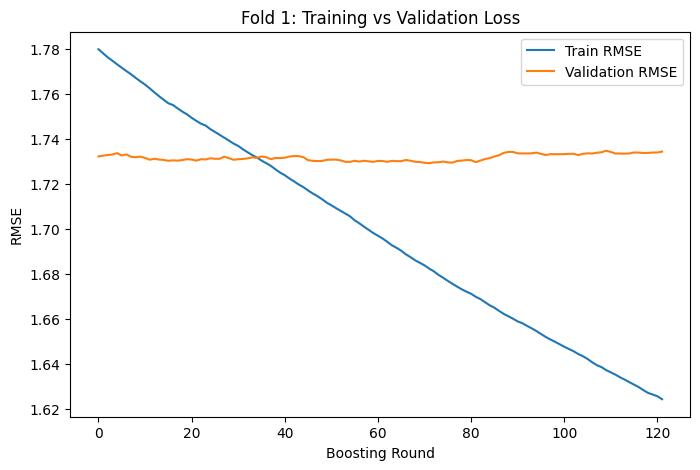

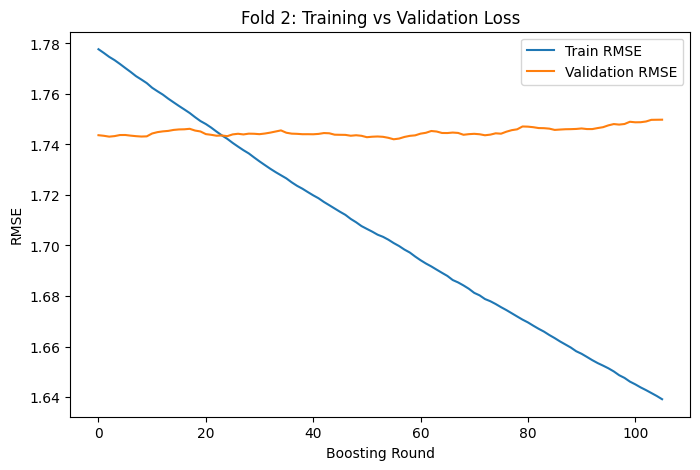

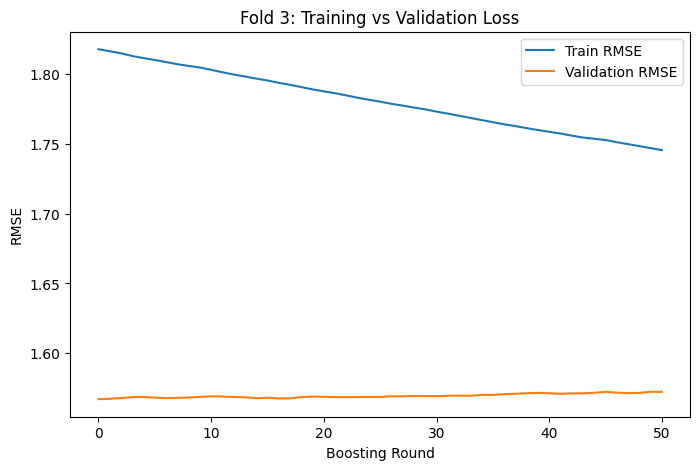

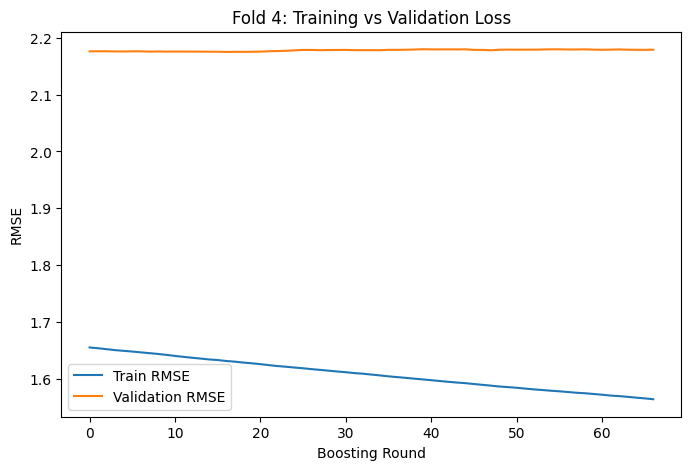

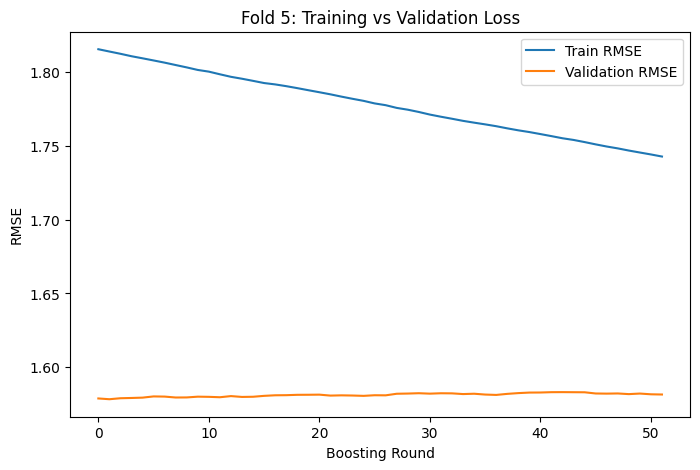

XGBoost RMSEs: [1.7292687892913818, 1.7420457601547241, 1.5669503211975098, 2.175201654434204, 1.5782610177993774]
Mean XGBoost RMSE: 1.7583455085754394
Std XGBoost RMSE: 0.22088129178933763

Train R2s: [0.10840469598770142, 0.08606189489364624, 0.001662909984588623, 0.03042733669281006, 0.0035039186477661133]
Mean Train R2: 0.04601215124130249

Test R2s: [0.0037323832511901855, -0.0014513731002807617, 0.00024324655532836914, -0.008551836013793945, -0.0033457279205322266]
Mean Test R2: -0.0018746614456176757

Test MAEs: [1.1966160535812378, 1.1541106700897217, 1.1250473260879517, 1.3299497365951538, 1.1433022022247314]
Mean Test MAE: 1.1898051977157593

Mean R / correlation: 0.02998956228643821

Compare to just predicting mean
Dummy RMSEs: [1.7327351570129395, 1.7428838014602661, 1.5671416521072388, 2.1757924556732178, 1.5782510042190552]
Mean Dummy RMSE: 1.7593608140945434
Std Dummy RMSE: 0.2209727128568249

Best individual predictions:


,row_index,actual_log_roi,predicted_log_roi,error,abs_error,title
1264,1159,0.702835,0.704743,0.001908,0.001908,Bad Lieutenant
399,650,0.710428,0.713005,0.002576,0.002576,Sharky's Machine
942,819,0.769563,0.774449,0.004886,0.004886,Superman IV: The Quest for Peace
208,1039,0.663366,0.657442,-0.005924,0.005924,Tron
824,222,0.763528,0.756531,-0.006997,0.006997,Only God Forgives
470,1010,0.723053,0.730058,0.007005,0.007005,Sleepy Hollow
1020,1201,0.842535,0.834010,-0.008525,0.008525,Casino
1002,1101,0.785489,0.776864,-0.008625,0.008625,Courage Under Fire
36,196,0.679177,0.689234,0.010057,0.010057,Jennifer's Body
343,409,0.635331,0.646212,0.010881,0.010881,The Last of the Mohicans



Worst individual predictions:


,row_index,actual_log_roi,predicted_log_roi,error,abs_error,title
914,696,14.699032,0.810802,-13.888230,13.888230,Eyes Wide Shut
1037,1295,13.240955,0.841136,-12.399819,12.399819,Mute Witness
426,798,-8.599023,0.720420,9.319443,9.319443,Shock Treatment
34,184,-7.647575,0.763520,8.411095,8.411095,The Gardener
411,713,-7.579533,0.816495,8.396028,8.396028,Ginger Snaps
844,349,-7.214377,0.828285,8.042663,8.042663,Hellraiser
979,998,-7.036195,0.824469,7.860663,7.860663,The Searchers
945,827,-6.560559,0.790048,7.350607,7.350607,The Curse of the Cat People
339,374,-6.272237,0.727848,7.000085,7.000085,Walkabout
918,728,-6.141125,0.766808,6.907933,6.907933,Jesse James


In [3]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

kf = KFold(n_splits=5, shuffle=True, random_state=42)
# n_splits = 5 --> 80/20 train/test split each fold

rmses = []
dummy_rmses = []
rs = []
test_r2s = []
train_r2s = []
test_maes = []

all_y_val = []
all_preds = []
all_val_indices = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        max_depth=2,
        learning_rate=0.02,
        n_estimators=2000,
        subsample=0.9,
        colsample_bytree=0.3,
        min_child_weight=5,
        reg_lambda=10,
        reg_alpha=1,
        random_state=42,
        early_stopping_rounds=50
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False
    )

    train_preds = model.predict(X_train)
    preds = model.predict(X_val)

    all_y_val.extend(y_val)
    all_preds.extend(preds)
    all_val_indices.extend(val_idx)

    rmse = root_mean_squared_error(y_val, preds)
    r = np.corrcoef(y_val, preds)[0, 1]
    test_r2 = r2_score(y_val, preds)
    train_r2 = r2_score(y_train, train_preds)
    test_mae = mean_absolute_error(y_val, preds)

    rmses.append(rmse)
    rs.append(r)
    test_r2s.append(test_r2)
    train_r2s.append(train_r2)
    test_maes.append(test_mae)

    dummy_preds = np.full_like(y_val, y_train.mean())
    dummy_rmse = root_mean_squared_error(y_val, dummy_preds)
    dummy_rmses.append(dummy_rmse)

    # Plot training vs validation loss
    results = model.evals_result()
    train_loss = results["validation_0"]["rmse"]
    val_loss = results["validation_1"]["rmse"]

    plt.figure(figsize=(8, 5))
    plt.plot(train_loss, label="Train RMSE")
    plt.plot(val_loss, label="Validation RMSE")
    plt.xlabel("Boosting Round")
    plt.ylabel("RMSE")
    plt.title(f"Fold {fold}: Training vs Validation Loss")
    plt.legend()
    plt.show()

all_y_val = np.array(all_y_val)
all_preds = np.array(all_preds)
all_val_indices = np.array(all_val_indices)

# Per-movie prediction errors
errors = all_preds - all_y_val
abs_errors = np.abs(errors)

prediction_df = pd.DataFrame({
    "row_index": all_val_indices,
    "actual_log_roi": all_y_val,
    "predicted_log_roi": all_preds,
    "error": errors,
    "abs_error": abs_errors
})

# Optional: add movie title if df_meta has a title column
if "title" in df_meta.columns:
    prediction_df["title"] = df_meta.iloc[all_val_indices]["title"].values

best_predictions = prediction_df.sort_values("abs_error").head(10)
worst_predictions = prediction_df.sort_values("abs_error", ascending=False).head(10)

print("XGBoost RMSEs:", rmses)
print("Mean XGBoost RMSE:", np.mean(rmses))
print("Std XGBoost RMSE:", np.std(rmses))

print("\nTrain R2s:", train_r2s)
print("Mean Train R2:", np.mean(train_r2s))

print("\nTest R2s:", test_r2s)
print("Mean Test R2:", np.mean(test_r2s))

print("\nTest MAEs:", test_maes)
print("Mean Test MAE:", np.mean(test_maes))

print("\nMean R / correlation:", np.mean(rs))

print("\nCompare to just predicting mean")
print("Dummy RMSEs:", dummy_rmses)
print("Mean Dummy RMSE:", np.mean(dummy_rmses))
print("Std Dummy RMSE:", np.std(dummy_rmses))

print("\nBest individual predictions:")
display(best_predictions)

print("\nWorst individual predictions:")
display(worst_predictions)

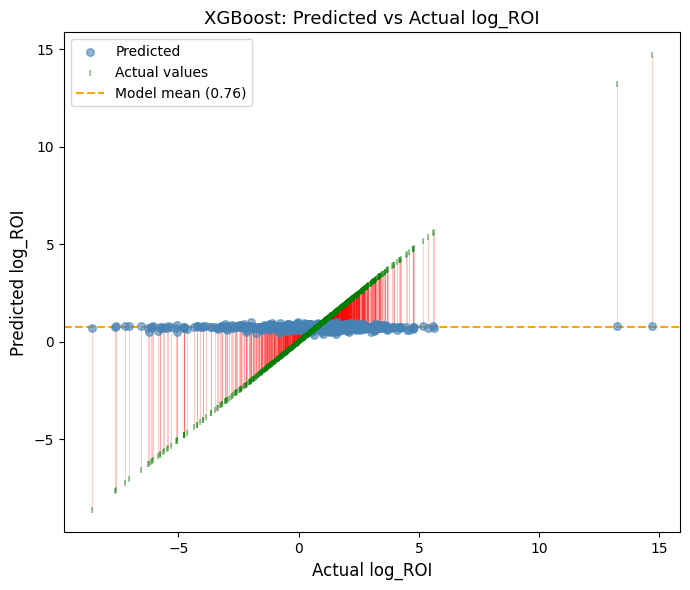

In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7, 6))

# Draw vertical lines from each prediction down to its actual value
# This shows the error for every film visually
for actual, pred in zip(all_y_val, all_preds):
    ax.plot([actual, actual], [actual, pred],
            color="red", alpha=0.2, linewidth=0.8)

# Plot the dots on top
ax.scatter(all_y_val, all_preds,
           alpha=0.6, color="steelblue", s=30, label="Predicted", zorder=3)

# Plot actual values as markers on the x axis
ax.scatter(all_y_val, all_y_val,
           alpha=0.4, color="green", s=15, marker="|",
           label="Actual values", zorder=3)

# Model mean line
ax.axhline(y=np.mean(all_preds), color='orange',
           linewidth=1.5, linestyle='--',
           label=f"Model mean ({np.mean(all_preds):.2f})")

ax.set_xlabel("Actual log_ROI", fontsize=12)
ax.set_ylabel("Predicted log_ROI", fontsize=12)
ax.set_title("XGBoost: Predicted vs Actual log_ROI", fontsize=13)
ax.legend()

plt.tight_layout()
plt.savefig(f"{BASE}/actual_vs_predicted.png", dpi=150)
plt.show()